In [29]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import timm
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter


In [30]:

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')


Using device: cuda


In [31]:

# 2. Data Directories
data_dir = r"C:\Users\shres\Documents\dataset\RSCD_Dataset"
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')


In [32]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    #transforms.RandomAffine(degrees=20, translate=(0.2, 0.2), scale=(0.7, 1.3)),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (simpler)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets with new transforms
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, val_transform)
test_dataset = datasets.ImageFolder(test_dir,test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print(f'Classes: {class_names}')


Classes: ['asphalt_damp', 'asphalt_dry', 'asphalt_verywet', 'asphalt_wet', 'cobble_damp', 'cobble_dry', 'cobble_verywet', 'cobble_wet', 'concrete_damp', 'concrete_dry', 'concrete_verywet', 'concrete_wet', 'fresh_snow', 'fully_packed', 'partially_covered']


In [33]:

# Define model and load checkpoint
model = timm.create_model('rexnet_100', pretrained=False)  # pretrained=False to avoid overwriting weights
num_features = model.get_classifier().in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

# Load trained weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()



C:\Users\shres\AppData\Local\Temp\ipykernel_22332\1679505104.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

RexNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (features): Sequential(
    (0): LinearBottleneck(
      (conv_dw): ConvNormAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
      (act_dw): ReLU6()
      (conv_pwl): ConvNormAct(
        (conv): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (1): LinearBottlene

In [34]:

from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight
num_epochs = 25

# Calculate class weights (same as your original)
labels = train_dataset.targets
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer with weight decay
#optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
#optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Learning rate scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Early stopping setup
best_val_loss = float('inf')
patience = 5
trigger_times = 0


In [35]:
def evaluate_model(model, dataloader, train_class_names, train_class_to_idx):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    idx_to_class = {v: k for k, v in train_class_to_idx.items()}

    # Verify this matches your actual test dataset labels
    test_label_map = {
        0: 'Dry',
        1: 'Wet',
        2: 'Snow'
    }

    # Mapping from training classes to test classes
    label_map = {
        'Dry': ["asphalt_dry", "cobble_dry", "concrete_dry"],
        'Wet': [
            "asphalt_wet", "asphalt_verywet", "asphalt_damp",
            "cobble_wet", "cobble_verywet", "cobble_damp",
            "concrete_wet", "concrete_verywet", "concrete_damp"
        ],
        'Snow': ["fresh_snow", "fully_packed", "partially_covered"]
    }

    # Create reverse mapping from training classes to test classes
    model_class_to_test_class = {}
    for test_label, model_classes in label_map.items():
        for c in model_classes:
            model_class_to_test_class[c] = test_label

    y_true_coarse = []
    y_pred_coarse = []
    y_true_fine = []
    y_pred_fine = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for true_label, pred_idx in zip(labels.cpu().numpy(), preds.cpu().numpy()):
                true_test_class = test_label_map.get(true_label, f"Unknown_{true_label}")
                pred_class_name = idx_to_class.get(pred_idx, "Unknown")
                pred_test_class = model_class_to_test_class.get(pred_class_name, "Unknown")
                
                if true_test_class in test_label_map.values() and pred_test_class != "Unknown":
                    y_true_coarse.append(true_test_class)
                    y_pred_coarse.append(pred_test_class)
                    y_true_fine.append(true_test_class)
                    y_pred_fine.append(pred_class_name)

    # Debug: Print some samples of the mapping
    print(f"Sample of true vs predicted mappings (first 10):")
    for true, pred in zip(y_true_coarse[:10], y_pred_coarse[:10]):
        print(f"True: {true}, Pred: {pred}")
    
    # Coarse classification report
    print("\n📊 Classification Report (Coarse:):")
    print(classification_report(y_true_coarse, y_pred_coarse, target_names=["Dry", "Wet", "Snow"]))
    
    # Check if we have any predictions
    if not y_true_coarse:
        print("Warning: No valid predictions were made!")
        return

    # Fine-grained confusion matrix
    # We need to manually build this since y_true and y_pred have different labels
    cm_labels_true = ["Dry", "Wet", "Snow"]
    cm_labels_pred = train_class_names
    
    # Initialize empty confusion matrix
    confusion_mat = np.zeros((len(cm_labels_true), len(cm_labels_pred)), dtype=int)
    
    # Create a mapping from training class names to their indices
    pred_class_to_idx = {name: idx for idx, name in enumerate(cm_labels_pred)}
    
    # Populate the confusion matrix
    for true, pred in zip(y_true_fine, y_pred_fine):
        true_idx = cm_labels_true.index(true)
        pred_idx = pred_class_to_idx[pred]
        confusion_mat[true_idx, pred_idx] += 1
    
    # Normalize the confusion matrix to show percentages
    confusion_mat_perc = confusion_mat.astype('float') / confusion_mat.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 8))
    
    # Plot counts
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", 
                xticklabels=cm_labels_pred, yticklabels=cm_labels_true)
    plt.xlabel("Predicted Label (Training Class)")
    plt.ylabel("True Label (Test Set)")
    plt.title("Confusion Matrix (Counts)")
    plt.xticks(rotation=45, ha='right')
    
    # Plot percentages
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_mat_perc, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=cm_labels_pred, yticklabels=cm_labels_true)
    plt.xlabel("Predicted Label (Training Class)")
    plt.ylabel("True Label (Test Set)")
    plt.title("Confusion Matrix (Percentages)")
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

Sample of true vs predicted mappings (first 10):
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Snow
True: Dry, Pred: Wet
True: Dry, Pred: Snow
True: Dry, Pred: Snow

📊 Classification Report (Coarse:):
              precision    recall  f1-score   support

         Dry       0.14      0.00      0.00      4700
         Wet       0.48      0.81      0.60      9400
        Snow       0.27      0.17      0.21      4700

    accuracy                           0.45     18800
   macro avg       0.30      0.33      0.27     18800
weighted avg       0.34      0.45      0.36     18800



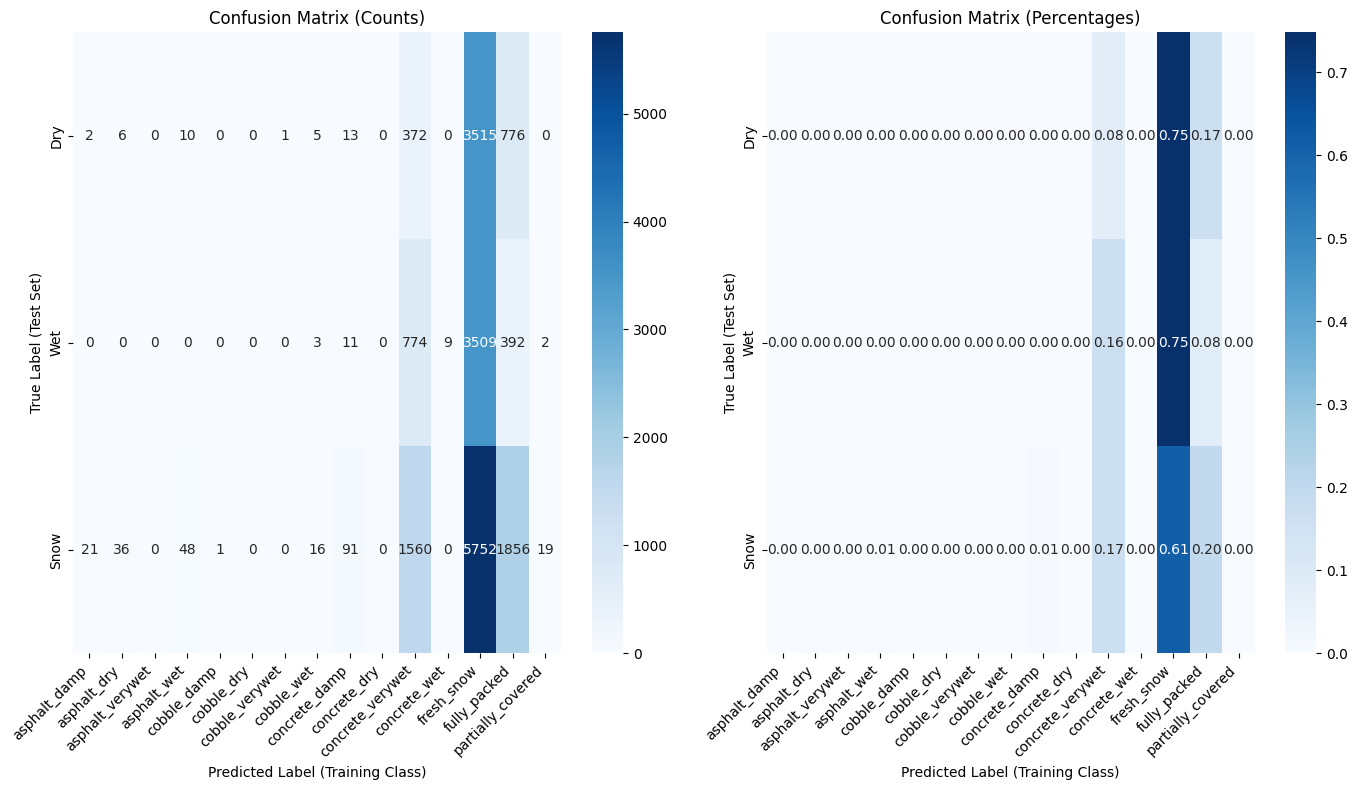

In [36]:
evaluate_model(model, test_loader, class_names, train_dataset.class_to_idx)